In [29]:
import numpy as np
from ase.db import connect
import matplotlib.pyplot as plt

In [30]:
def read_ase_db(file_path):
    energies = []
    forces = []
    with connect(file_path) as db:
        for row in db.select():
            energies.append(row.energy)
            forces.append(row.forces)
    return np.array(energies), np.array(forces)

In [31]:
db_file1 = "/LARGE0/gr10563/kai/scripts/abn2db/test/job_02/dft.db"
db_file2 = "/LARGE0/gr10563/kai/scripts/abn2db/test/job_02/mlff.db"

energies1, forces1 = read_ase_db(db_file1)
energies2, forces2 = read_ase_db(db_file2)

In [32]:
def get_number_of_atoms(file_path):
    with connect(file_path) as db:
        for row in db.select():
            return row.natoms

n_atoms1 = get_number_of_atoms(db_file1)
n_atoms2 = get_number_of_atoms(db_file2)

print("Number of atoms in db_file1:", n_atoms1)
print("Number of atoms in db_file2:", n_atoms2)

Number of atoms in db_file1: 36
Number of atoms in db_file2: 36


In [33]:
energies1_diff = energies1 - energies1[0]
energies2_diff = energies2 - energies2[0]

In [34]:
max_1, min_1 = np.max(energies1), np.min(energies1)
max_2, min_2 = np.max(energies2), np.min(energies2)
print("DFT: max = {}, min = {}".format(max_1, min_1))
print("MLFF: max = {}, min = {}".format(max_2, min_2))

DFT: max = -228.31006123, min = -282.01127978
MLFF: max = -235.15084236, min = -281.97402215


In [35]:
max_1, min_1 = np.max(forces1), np.min(forces1)
max_2, min_2 = np.max(forces2), np.min(forces2)
print("DFT: max = {}, min = {}".format(max_1, min_1))
print("MLFF: max = {}, min = {}".format(max_2, min_2))

DFT: max = 50.046432, min = -49.798597
MLFF: max = 10.952991, min = -12.748228


In [36]:
def find_max_energy_id(db_file):
    with connect(db_file) as db:
        max_energy = -1e10
        max_id = -1
        for row in db.select():
            if row.energy > max_energy:
                max_energy = row.energy
                max_id = row.id
        return max_id

In [37]:
max_id1 = find_max_energy_id(db_file1)
print("Max energy id in db_file1:", max_id1)

Max energy id in db_file1: 249


In [68]:
def find_max_forces_id(db_file):
    with connect(db_file) as db:
        max_forces = -1e10
        max_id = -1
        for row in db.select():
            for i in range(len(row.forces)):
                if any(row.forces[i] > max_forces):
                    max_forces = row.forces[i]
                    max_id = row.id
        return max_id

In [69]:
max_id1 = find_max_forces_id(db_file1)
print("Max forces id in db_file1:", max_id1)

Max forces id in db_file1: 309


In [ ]:
max_id1 = find_max_forces_id(db_file1)
print("Max forces id in db_file1:", max_id1)

In [38]:
#db1 = connect(db_file1)
#db2 = connect(db_file2)

#del db1[max_id1]
#del db2[max_id1]

In [48]:
def plot_energies(energies1, energies2, n_atoms, step=25, color="#1f77b4", fontsize=18, labelsize=14, show=True, save=False):
    max_1, min_1 = np.max(energies1), np.min(energies1)
    max_2, min_2 = np.max(energies2), np.min(energies2)

    max_value = max(max_1, max_2)
    min_value = min(min_1, min_2)
    max_value = (np.ceil(max_value / step) * step)
    min_value = (np.floor(min_value / step) * step)

    rmse = np.sqrt(np.mean((energies1 - energies2) ** 2))
    rmse_per_atom = rmse / n_atoms

    # Define the figure
    fig, ax = plt.subplots(dpi=200)

    ax.plot(
        [min_value, max_value], 
        [min_value, max_value], 
        "k--", linewidth=1.5, zorder=2
    )

    # Plot the data
    for x, y in zip(energies1, energies2):
        ax.plot(
            [x, x], [x, y], 
            color="grey", linestyle=":", 
            linewidth=1.5, zorder=1
        )

        ax.scatter(x, y, zorder=4, color=color, alpha=0.5)

    # Add title and labels
    ax.set_xlabel("DFT results (eV)", fontsize=fontsize)
    ax.set_ylabel("MLFF results (eV)", fontsize=fontsize)

    ax.text(
        0.95, 0.13, f"RMSE: {rmse:.2f} eV",
        horizontalalignment="right",
        transform=ax.transAxes, fontsize=labelsize
    )

    ax.text(
        0.95, 0.05, f"RMSE/atom: {rmse_per_atom*1000:.1f} meV/atom",
        horizontalalignment="right",
        transform=ax.transAxes, fontsize=labelsize
    )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim([min_value, max_value])
    ax.set_ylim([min_value, max_value])
    ax.set_xticks(np.arange(min_value, max_value+1, step))
    ax.set_yticks(np.arange(min_value, max_value+1, step))
    ax.tick_params(
        axis='both', which='major', 
        labelsize=labelsize, width=2
    )

    # Set the linewidth of each axis
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    # Save the figure
    fig.tight_layout()

    if save:
        fig_name = f"{fig_name}.png"
        fig_path = os.path.join(fig_dir, fig_name)
        plt.savefig(fig_path, dpi=600)
        print(f"Figure saved as {fig_path}")

    if not show:
        plt.close()

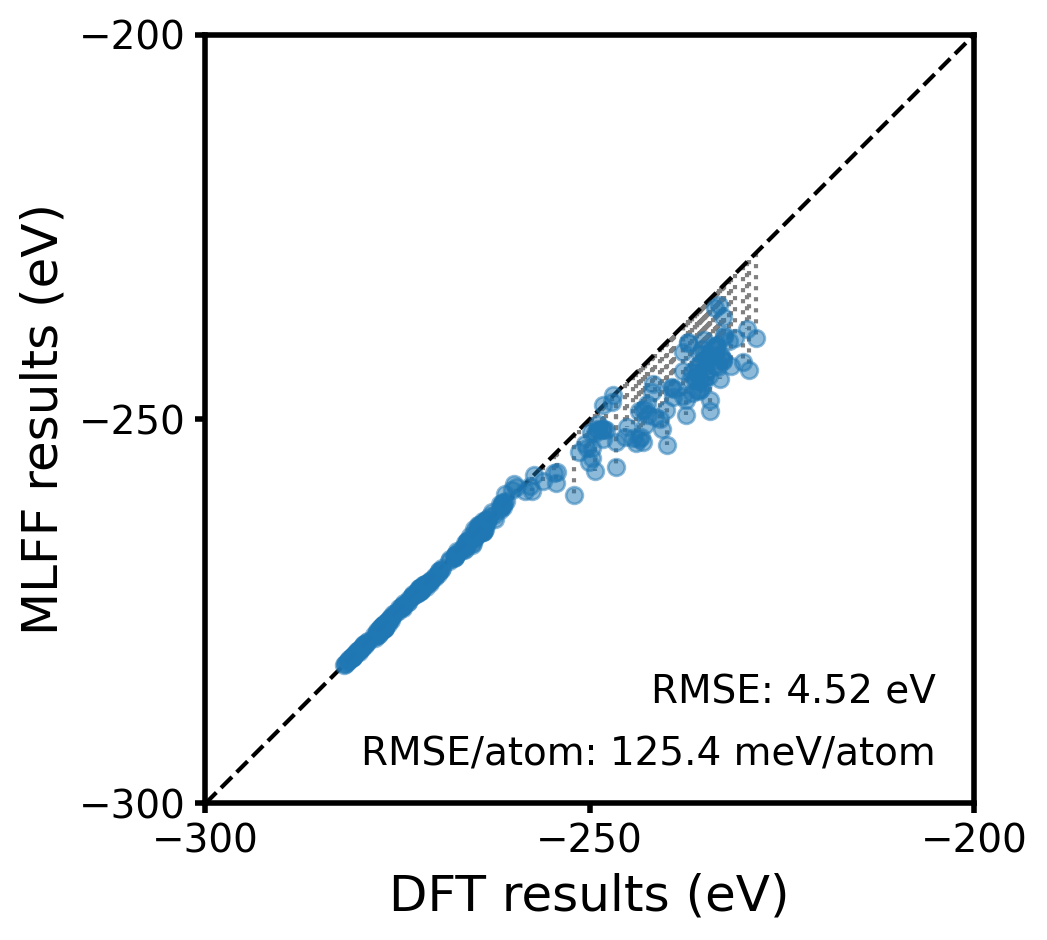

In [49]:
plot_energies(energies1, energies2, n_atoms1, step=50)

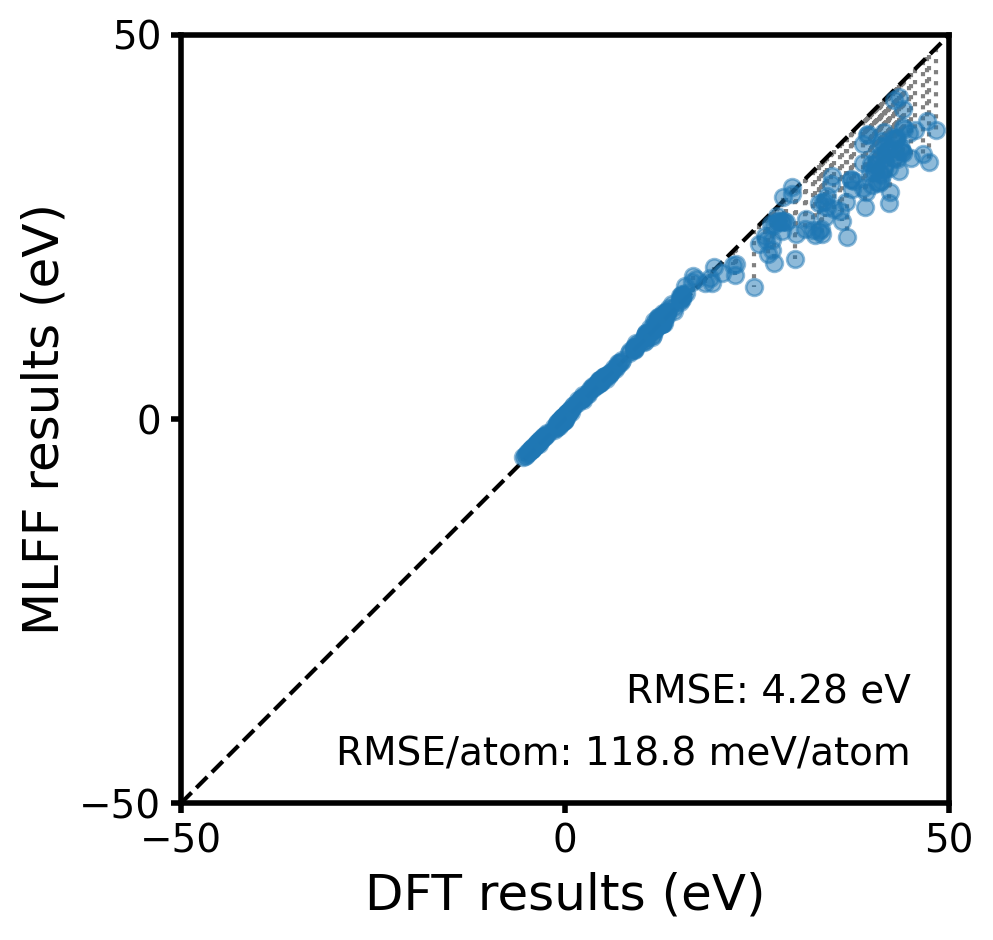

In [50]:
plot_energies(energies1_diff, energies2_diff, n_atoms1, step=50)

In [93]:
def plot_forces(forces1, forces2, n_atoms, step=25, color_list=["#1f77b4", "#ff7f0e", "#2ca02c"], fontsize=18, labelsize=14, show=True, save=False):
    max_1, min_1 = np.max(forces1), np.min(forces1)
    max_2, min_2 = np.max(forces2), np.min(forces2)

    max_value = max(max_1, max_2)
    min_value = min(min_1, min_2)
    max_value = (np.ceil(max_value / step) * step)
    min_value = (np.floor(min_value / step) * step)

    rmse = np.sqrt(np.mean((forces1 - forces2) ** 2))
    rmse_per_atom = rmse / n_atoms

    # Define the figure
    fig, ax = plt.subplots(dpi=200)

    ax.plot(
        [min_value, max_value], 
        [min_value, max_value], 
        "k--", linewidth=1.5, zorder=2
    )

    # Plot the data
    """
    for i, (f1, f2) in enumerate(zip(forces1, forces2)):
        for j, (x, y) in enumerate(zip(f1.flatten(), f2.flatten())):
            color = color_list[j % 3]
            ax.plot(
                [x, x], [x, y], 
                color="grey", linestyle=":", 
                linewidth=1.5, zorder=1
            )
            ax.scatter(x, y, zorder=4, color=color, alpha=0.5)
    """

    directions = ["x", "y", "z"]
    for f1, f2 in zip(forces1, forces2):
        for f11, f22 in zip(f1, f2):
            for j in range(3):
                """
                ax.plot(
                    [f11[j], f11[j]], [f11[j], f22[j]], 
                    color="grey", linestyle=":", 
                    linewidth=1.5, zorder=1
                )
                """
                ax.scatter(f11[j], f22[j], zorder=4, color=color_list[j], alpha=0.5, label=directions[j])

    #ax.scatter(forces1[:, 0], forces2[:, 0], zorder=4, color=color_list[0], alpha=0.5, label="x")
    #ax.scatter(forces1[:, 1], forces2[:, 1], zorder=4, color=color_list[1], alpha=0.5, label="y")
    #ax.scatter(forces1[:, 2], forces2[:, 2], zorder=4, color=color_list[2], alpha=0.5, label="z")

    # Add title and labels
    ax.set_xlabel("DFT results (eV/Å)", fontsize=fontsize)
    ax.set_ylabel("MLFF results (eV/Å)", fontsize=fontsize)

    ax.text(
        0.95, 0.13, f"RMSE: {rmse:.2f} eV/Å",
        horizontalalignment="right",
        transform=ax.transAxes, fontsize=labelsize
    )

    ax.text(
        0.95, 0.05, f"RMSE/atom: {rmse_per_atom*1000:.1f} meV/(Å·atom)",
        horizontalalignment="right",
        transform=ax.transAxes, fontsize=labelsize
    )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim([min_value, max_value])
    ax.set_ylim([min_value, max_value])
    ax.set_xticks(np.arange(min_value, max_value+1, step))
    ax.set_yticks(np.arange(min_value, max_value+1, step))
    ax.tick_params(
        axis='both', which='major', 
        labelsize=labelsize, width=2
    )

    # Set the linewidth of each axis
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    # Add legend
    #ax.legend(['x', 'y', 'z'], loc='upper left', fontsize=labelsize)
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    ax.legend(
        by_label.values(), by_label.keys(), 
        fontsize=labelsize, handlelength=0.5
    )

    # Save the figure
    fig.tight_layout()

    if save:
        fig_name = f"{fig_name}.png"
        fig_path = os.path.join(fig_dir, fig_name)
        plt.savefig(fig_path, dpi=600)
        print(f"Figure saved as {fig_path}")

    if not show:
        plt.close()

In [94]:
max_1, min_1 = np.max(forces1), np.min(forces1)
max_2, min_2 = np.max(forces2), np.min(forces2)
print("DFT: max = {}, min = {}".format(max_1, min_1))
print("MLFF: max = {}, min = {}".format(max_2, min_2))

DFT: max = 50.046432, min = -49.798597
MLFF: max = 10.952991, min = -12.748228


In [95]:
for forces in forces1[0]:
    print(forces)

[2.380000e-04 1.600000e-05 5.399819e+00]
[-1.035000e-03 -1.620000e-04  5.401928e+00]
[-1.89000e-04 -4.53000e-04 -3.63298e-01]
[ 1.70000e-04 -2.78000e-04 -3.44636e-01]
[-2.90000e-05  4.78000e-04 -3.44526e-01]
[ 7.70000e-05  4.42000e-04 -3.63662e-01]
[-0.002045  0.001434  0.315114]
[0.002513 0.002254 0.289708]
[-0.001779 -0.001966  0.28986 ]
[ 0.00143  -0.001803  0.31611 ]
[-5.360000e-04 -5.800000e-04 -5.456311e+00]
[ 1.109000e-03 -6.700000e-04 -5.444996e+00]
[ 1.428797 -0.004182 -1.186734]
[-1.42946   0.004274 -1.187588]
[ 0.004206 -1.429173 -1.186761]
[-0.004231  1.428286 -1.186448]
[-1.428337  0.004176 -1.186383]
[ 1.429409 -0.004355 -1.187108]
[-0.004277  1.429779 -1.187275]
[ 0.004275 -1.428745 -1.187019]
[0.019299 0.021436 0.026774]
[-0.018869 -0.020327  0.025295]
[-0.021644 -0.019409  0.026809]
[0.02159  0.020328 0.027301]
[-0.020544 -0.021378  0.027102]
[0.020143 0.02024  0.025807]
[0.020027 0.018947 0.025329]
[-0.020096 -0.019827  0.025883]
[-0.005446  1.473374  1.206842]
[ 0.00

In [96]:
forces1[:,:,1]

array([[ 1.600000e-05, -1.620000e-04, -4.530000e-04, ...,  1.472162e+00,
        -5.125000e-03,  4.297000e-03],
       [ 3.044000e-03,  3.773000e-03,  4.972800e-02, ...,  1.445637e+00,
        -9.099000e-03, -1.419100e-02],
       [ 3.843000e-03,  5.919000e-03,  9.639100e-02, ...,  1.409839e+00,
        -1.258000e-02, -2.367900e-02],
       ...,
       [-9.464510e-01, -2.972374e+00, -1.648615e+00, ..., -2.958240e-01,
        -3.241070e-01, -2.158490e-01],
       [-1.280007e+00, -1.334248e+00, -9.045910e-01, ..., -7.664090e-01,
         1.105362e+00,  1.790660e-01],
       [-1.310964e+00,  1.622244e+00, -2.371320e-01, ..., -5.457510e-01,
         9.343490e-01, -2.731530e-01]])

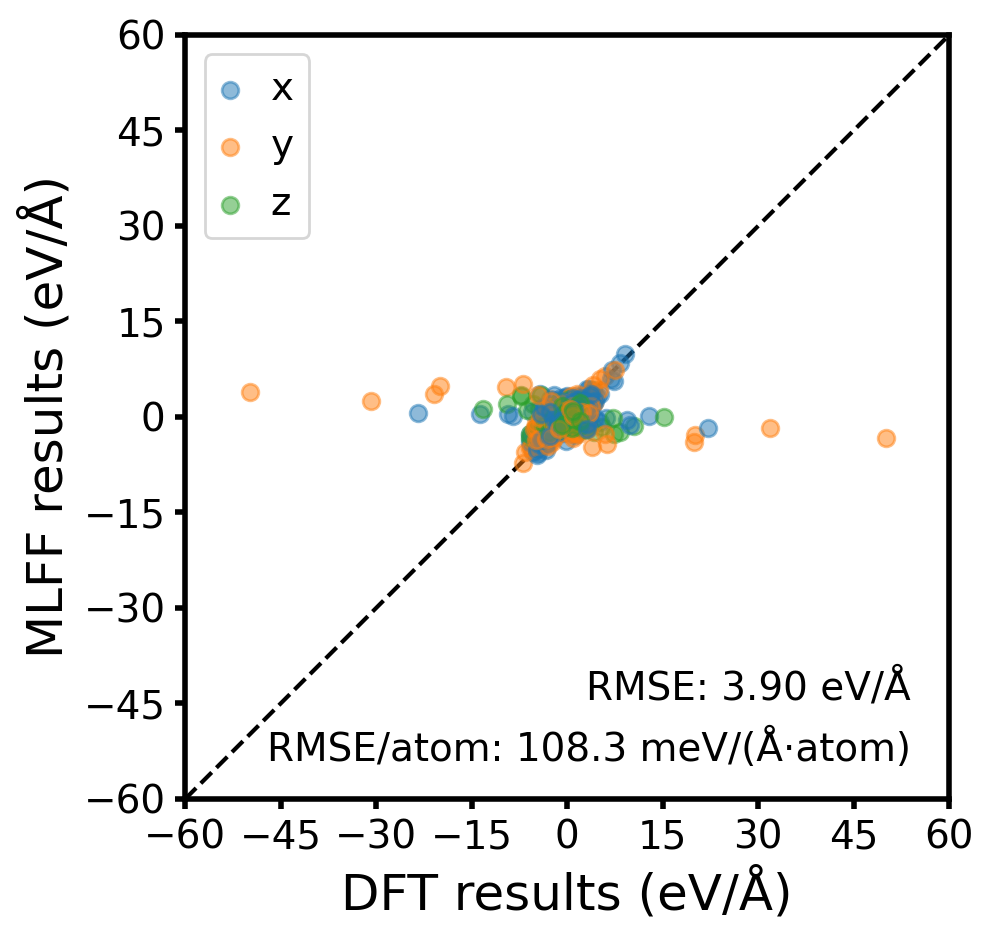

In [97]:
plot_forces(forces1[210:220], forces2[210:220], n_atoms1, step=15)